# Week 2: The Baseline CNN

## Methods

This notebook establishes the baseline CNN model for deepfake detection using EfficientNet-B0.

**Architecture:** EfficientNet-B0 was selected for its strong performance-to-parameter ratio
and widespread use as a baseline in deepfake detection literature. The model was loaded with
ImageNet-pretrained weights via the `timm` library. All layers were frozen except the
classification head and the last two convolutional blocks, which were fine-tuned for binary
classification (fake=0, real=1).

**Class Imbalance Handling:** Two strategies were used: (1) a WeightedRandomSampler with
inverse class frequency weights to balance batch composition during training, and (2) weighted
cross-entropy loss (fake: 1.00, real: 6.88) to penalize misclassification of the
underrepresented real class.

**Key Hyperparameters:**
| Parameter | Value |
|---|---|
| Optimizer | Adam |
| Learning rate | 1e-4 |
| LR scheduler | ReduceLROnPlateau (patience: 2, factor: 0.5) |
| Batch size | 64 |
| Max epochs | 10 |
| Loss | Weighted CrossEntropyLoss |
| Data augmentation | Horizontal flip, rotation (±10°), color jitter |
| Normalization | ImageNet mean/std |
| GPU | NVIDIA Tesla T4 (Colab Pro) |

**Evaluation Metrics:** Given the class imbalance, macro F1 is used as the primary evaluation
metric rather than overall accuracy. AUC-ROC provides a threshold-independent measure.
Per-class precision, recall, and F1 are reported to identify class-specific failure modes.

Mount Google Drive and unzip frames to local runtime.

In [ ]:
#mounting google drive and unzipping frames.zip
from google.colab import drive
drive.mount('/content/drive')
!unzip -q -o /content/drive/MyDrive/deepfake_capstone/frames.zip -d /content/

Mounted at /content/drive
A
A


Import required libraries. GPU verification confirms T4 allocation; A100 is reserved for ViT training in Weeks 3–4.


In [ ]:
#importing libraries and modules to be used for week2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
#torches  are used for the building and training of this weeks model.
import timm
#the pytorch image models library which has EfficientNet
import numpy as np
#array management and such through out
import matplotlib.pyplot as plt
#plots
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
#sklearn will be used for model eval
from tqdm import tqdm
#progress bars for kernel progression for the long running ones to glance at progress
import os, copy, random
#os is for saving at the end and copy will make the copy to save. Random is for seed generating.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")
if torch.cuda.is_available():
  print(f"GPU: {torch.cuda.get_device_name(0)}")

Using: cuda
GPU: Tesla T4


In [1]:
SEED = 301
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# Paths
DATA_DIR = '/content/frames'
CHECKPOINT_DIR = '/content/drive/MyDrive/deepfake_capstone/checkpoints/'
RESULTS_DIR = '/content/drive/MyDrive/deepfake_capstone/results/'

#Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 10

LEARNING_RATE = 1e-4

NameError: name 'random' is not defined

**Setting up the data and the transformers**

The transforms.Normalize() is used to normalize the RGB channels and account for standard deviation in them. EfficientNet cannot run without Normalize as it expects data to be normed the same as ImageNet was which is what it was trained on.

transforms.RandomHorizontalFlip() flips images horizontally randomly so that the model recognizes objects and such regardless of left or right orientation.

transforms.RandomRotation() set to 10, which means that the image will rotate at a range of -10 to +10 degrees. This helps the model regonize even with slight variance in the object orientation.

transforms.ColorJitter() will randomly change the brightness and contrast of the images, making the model less sensitive about lighting conditions for an object.

--------------
val_transform is used for val and test data, and is not as heavy because no augmentation is done here because we are evaluating the model at this stage and seeing how well it is able to generalize.

In [ ]:
#setting up the data
data_dir = '/content/frames' # It is for some reason nesting this week so may need to be adjusted later to fix

# Was a bug hunting step from nesting but left as a just in case to fix

if not os.path.exists(data_dir):
    print(f"Error: Data directory '{data_dir}' does not exist. Please ensure frames.zip is unzipped.")
elif not os.listdir(data_dir):
    print(f"Warning: Data directory '{data_dir}' is empty. Please check the unzipping process.")
else:
    print(f"Contents of {data_dir}: {os.listdir(data_dir)}")


#transormer = EfficientNet which expects
#224x224, and ImageNet normalization
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])
#the normalize numbers on top are for the RGB channels
#then on the bottom is the standard deviation for the RGB

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

#loading datasets ImageFolder reads the real and fake subfolers
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), val_transform)

#print statements to double check and take a peek at some things
print(f"Classes: {train_dataset.classes}")
print(f"Class to index: {train_dataset.class_to_idx}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Contents of /content/frames/frames: ['train', 'test', 'val']
Classes: ['fake', 'real']
Class to index: {'fake': 0, 'real': 1}
Train: 195786, Val: 34636, Test: 20055


   **Class label orientation:** class_to_idx = {'fake': 0, 'real': 1}. Throughout all
   notebooks, probs[:, 1] represents the probability of "real." For deepfake detection
   evaluation, "fake" is treated as the positive class, a True Positive is a fake image
   correctly identified as fake.

This is further prep to the data for training, as seen in last week there is heavy imbalance between fake and real. So the idea here is to try and address it by doing a sampler that then sets up data loaders so its more efficient at batch processing.

---

So to address class imbalance we start with extracting the target labels from the train_dataset.samples. Then we get to count the occurence of fake and real in the training set and reprints that. The class_weights then will try to counteract by getting the inverse class weights so the class with the fewest samples will have a higher weight so the model pays more attention to the less seen class during training. That class is 'real' by the way.

Now we get to the DataLoaders, with the batch size as a constant set to 64 that is how many frames EfficientNet goes through before it updates weights. This is a case of time versus efficiency and  efficiency is slightly winning here. So now we get to the train_loader

train_loader creates the DataLoader object for the training set, does not auto shuffle and instead uses the handcrafted sampler. So WeightedRandomSampler is running it here by controlling the order and frequency of the samples in each batch. And num workers means we will have 2 subprocesses working at the same time to speed up the data loading.

val_loader is doing the same thing except no sampler here so the data is in a consistent manner, same thing is seen in test_loader.

In [ ]:
#Sampler of weights for class imbalance
train_targets = [s[1] for s in train_dataset.samples]
class_counts = np.bincount(train_targets)
#checking the class counts before continuing
print(f"Class counts fake: {class_counts[0]}, real: {class_counts[1]}")

#computing wights to get inverse freqency
class_weights = 1.0 / class_counts

sample_weights = [class_weights[t] for t in train_targets]

sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

#Dataloaders time
#const for batch size
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, sampler = sampler, num_workers = 2)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 2)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 2)

#printing the batches per epoch to double check

print(f"Batches per epoch, train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

Class counts fake: 170930, real: 24856
Batches per epoch, train: 3060, val: 542, test: 314


# Model Building and Training

**Model Building Time**

This sets up the neural network model, EfficientNet_b0, with its pretrained mode and the number of classes we have. b0 is smaller but still powerful so we can conserve resources here.

From the set up we now start freezing early layers. This is done to avoid retraining the early layers and keep the generalization EfficientNet learned from its massive training on ImageNet, thus also avoiding overfitting as much as we can. It also keeps the model computationaly efficient by lessening the number of params that we need to update during training without needing a boost in power. The shift from early layers means that attention to later layers is where training focuses to train on the specific issue, real v fake lil subtleties.

The unfreezing in later layers is for fine tuning (as seen in previous para) and also the actual layer that makes the class predictions on the model, especially since the number of classes is only two it needs to adjust the weights. The parameters we can train are counted and printed later.

**loss, optimizer, and scheduler**

This block sets up the fundamental guides of training the neural network. These are the loss function, optimizer, and the learning rate scheduler.


The loss function calculates specific weights to the class (the weight_tensor line) it will take, in essence, the ratio of majority:minority in classes and apply that as the weight_tensor. That is then moved to the resource and gives consistency when doing model computations. Criterion is set to the cross entropy loss object, which is a quite common loss function in multi class problems, which ours is. It calculates the difference between the model's predicted probabilities nad the true labels. Then by passing the weight_tensor we have the loss function apply a higher penalty for misclassifying in the minority class. This in essence tries to encourage the model to please pay more attention to the 'real' class.

The optimizer is set to Adam, which is an adaptive learning rate optimization algorithm. This will auto adject the learning rates for different parameters during the training later. The filter is key here with the freezing we did earlier, since requires_grad was set to True only the thawed layers will have the weights updated during training. The learning rate is then init at 0.0001. That controls the step size the optimizer updates the model weights.

Finally we have the learning rate scheduler. The scheduler is set to do a few different things in its arguments. The specific scheduler object is the ReduceLROnPlateau which basically means the scheduler dynamically adjusts the learning rate during training by monitoring the validation loss, and reduces the learning rate when it stops improves. It takes the previously declared optimizer, then its mode is set to min to make the scheduler look for a minimum in the validation loss. The patience is how many epochs it will wait if theres no improvement then drop the learning rate. The factor is how much the learning rate is dropped.


In [ ]:
#build and configuring the EfficientNet-B0

#this loads the pretrained EfficientNet-B0
model = timm.create_model('efficientnet_b0', pretrained = True, num_classes = 2)

#this will freeze early layers and unfreee the classifier and the last few blocks
for param in model.parameters():
  param.requires_grad = False

#unfreeze portion
for param in model.classifier.parameters():
  param.requires_grad = True

#this portion unfreezes the last two blocks
for param in model.blocks[-2:].parameters():
  param.requires_grad = True

model = model.to(device)

#this counts the trainable params so i know what i can touch
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

#prinitng the check
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

#

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Trainable params: 2,746,142 / 4,010,110 (68.5%)


In [ ]:
#now its time for loss, the optimizer, and the scheduler

#this weightesd loss helps with any residual imbalance that hasn't been touched
weight_tensor = torch.tensor([1.0, class_counts[0]/class_counts[1]], dtype = torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight = weight_tensor)

#print check for sanity
print(f"loss weights, fake: {weight_tensor[0]:.2f}, real: {weight_tensor[1]:.2f}")

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr = 1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', patience = 2, factor = 0.5)

loss weights, fake: 1.00, real: 6.88


# Training Time!

**training set up**

tqdm is used here to give a progress bar for the epochs for glance monitoring while its running.

Here we have to functions, train_one_epoch() and evaluate(). The first is what will execute as one pass over the training dataset one full time. The model goes to training mode which makes some layers behave differently. Then it inits running loss, correct, and total to track loss and accuracy for the current run. Every run it will iterate over the train_loader which provides the batch of images and labels. The images.to gives the batch and labels to the resource being used. The optimizer.zero_grad will clear the graidents of any and all optimized torch tensors. This is vital to the training because gradients will build up by default on Pytorch but we want to keep it clean for each batch. Then we have the outputs = model(images) which is the forward pass. This gives the raw predictions from the model. That then is used to calculate the differencce between the model and the actual label. Then we have the backward pass (loss.backward) which is where the gradients are comped and we see how each parameter contributes to the output.

The evaluate() is the evaluation pass over the dataset but it does not update the model weights. The model is put into eval mode to disable certain features. It is then inited with variables to track loss, accuracy, and data for AUC to be calculated later on. The no_grad() disables gradient calculation to reduce memory consumption and speeds up the computation time here since gradients are not needed here. It then iterates through the val_loader which does the similar thing to train_loader above. Then does the forward pass to calculate the loss, then finally calculates AUC-ROC.

**actual training**

This is where the plan starts to come together. We have epcohs set to 10, val auc init at 0.0, best model state init to None, and finally a history dictionary to store metrics of the loss, accuracy, and AUC. We also have early stopping at work here with its patience set to 3 for the cut off if there is no improvement and an assoicated count. Then we have the main training for loop that will run as specified to set, we call train_one_epoch, and evaluate. The scheduler updates the learning rate based on the validation loss. The history of the epoch is saved in the dictionary. The current_lr saves the epoch's learning rate for a plot later on. Then there is a print section to get the metrics for the current epoch to see the training as it goes.

When the loop finishes we need the best model to be saved for later comparisons. This is done by the best_val_auc init earlier, as the loop goes it saves current best model to best_model_state using the copy module. After the loop is finished the best model is pulled by model.load_state_dict(best_model_state) and then saved to the drive and confirms this.  

In [ ]:
#its training loop time!
def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for images, labels in tqdm(loader, desc = "Training", leave = False):
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * images.size(0)
    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()

  return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
  model.eval()
  running_loss = 0.0
  correct = 0
  total = 0
  all_probs = []
  all_labels = []

  with torch.no_grad():
    for images, labels in tqdm(loader, desc = "Evaluating", leave = False):
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)

      running_loss += loss.item() * images.size(0)
      _, predicted = outputs.max(1)
      total += labels.size(0)
      correct += predicted.eq(labels).sum().item()

      probs = torch.softmax(outputs, dim = 1)[:, 1] #prob of real
      all_probs.extend(probs.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  auc = roc_auc_score(all_labels, all_probs)
  return running_loss / total, correct / total, auc, all_probs, all_labels

In [ ]:
#training time

NUM_EPOCHS = 10
best_val_auc = 0.0
best_model_state = None
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}

# Early stopping parameters
early_stopping_patience = 3 # Number of epochs to wait if val_auc does not improve
epochs_no_improve_count = 0

for epoch in range(NUM_EPOCHS):
  train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
  val_loss, val_acc, val_auc, _, _ = evaluate(model, val_loader, criterion, device)
  scheduler.step(val_loss)

  history['train_loss'].append(train_loss)
  history['train_acc'].append(train_acc)
  history['val_loss'].append(val_loss)
  history['val_acc'].append(val_acc)
  history['val_auc'].append(val_auc)

  current_lr = optimizer.param_groups[0]['lr']

  #classic print statement check
  print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} AUC: {val_auc:.4f} | "
          f"LR: {current_lr:.6f}")

  #saving the best model and checking for early stopping
  if val_auc > best_val_auc:
    best_val_auc = val_auc
    best_model_state = copy.deepcopy(model.state_dict())
    epochs_no_improve_count = 0 # Reset counter if performance improves
    print(f"Best model saved with AUC: {best_val_auc:.4f}")
  else:
    epochs_no_improve_count += 1
    print(f"Validation AUC did not improve. Patience: {epochs_no_improve_count}/{early_stopping_patience}")

  if epochs_no_improve_count >= early_stopping_patience:
    print(f"Early stopping triggered after {early_stopping_patience} epochs without improvement.")
    break # Exit the training loop

#saving the model to my google drive
model.load_state_dict(best_model_state)
save_path = '/content/drive/MyDrive/deepfake_capstone/checkpoints/'
os.makedirs(save_path, exist_ok = True)
torch.save(model.state_dict(), os.path.join(save_path, 'efficientnet_b0_best.pth'))
print(f"Model saved to {save_path}, best model with val auc: {best_val_auc:.4f}")

Epoch 1/10 | Train Loss: 0.1011 Acc: 0.8905 | Val Loss: 0.7869 Acc: 0.7703 AUC: 0.7133 | LR: 0.000100
Best model saved with AUC: 0.7133


Epoch 2/10 | Train Loss: 0.0807 Acc: 0.9143 | Val Loss: 0.7775 Acc: 0.8022 AUC: 0.7228 | LR: 0.000100
Best model saved with AUC: 0.7228


Epoch 3/10 | Train Loss: 0.0706 Acc: 0.9266 | Val Loss: 0.8273 Acc: 0.8165 AUC: 0.7328 | LR: 0.000100
Best model saved with AUC: 0.7328


Epoch 4/10 | Train Loss: 0.0610 Acc: 0.9371 | Val Loss: 0.8860 Acc: 0.8031 AUC: 0.7213 | LR: 0.000100


Epoch 5/10 | Train Loss: 0.0544 Acc: 0.9447 | Val Loss: 0.7615 Acc: 0.8313 AUC: 0.7626 | LR: 0.000100
Best model saved with AUC: 0.7626


Epoch 6/10 | Train Loss: 0.0511 Acc: 0.9484 | Val Loss: 0.9137 Acc: 0.7879 AUC: 0.7559 | LR: 0.000100


Epoch 7/10 | Train Loss: 0.0460 Acc: 0.9543 | Val Loss: 1.0301 Acc: 0.7980 AUC: 0.7240 | LR: 0.000100


Epoch 8/10 | Train Loss: 0.0439 Acc: 0.9567 | Val Loss: 1.0358 Acc: 0.8052 AUC: 0.7294 | LR: 0.000050


Epoch 9/10 | Train Loss: 0.0339 Acc: 0.9660 | Val Loss: 1.0625 Acc: 0.8372 AUC: 0.7307 | LR: 0.000050


Training :):  25%|██▌       | 780/3060 [03:10<07:47,  4.87it/s]

**Note on training completion:** Training was interrupted during epoch 10. The best
   model was saved at epoch 5 based on validation AUC-ROC (0.7626). All test evaluation
   and metrics reported below use this epoch 5 checkpoint. The summary metrics (73.93%
   accuracy, 0.7706 test AUC-ROC) are from this saved checkpoint and are verified by
   the test evaluation cell output.

**Plots**


plot 1:


3 subplots that focus on: loss over epoch in train and val; accuracy of training and val over epoch, val auc ros over epochs.

plot 2:

prints the calculated test loss, accuracy, and auc roc score. Also prints a classification report that has precision, recall, and the f1 score for real and fake. Finally a confusion matrix display.

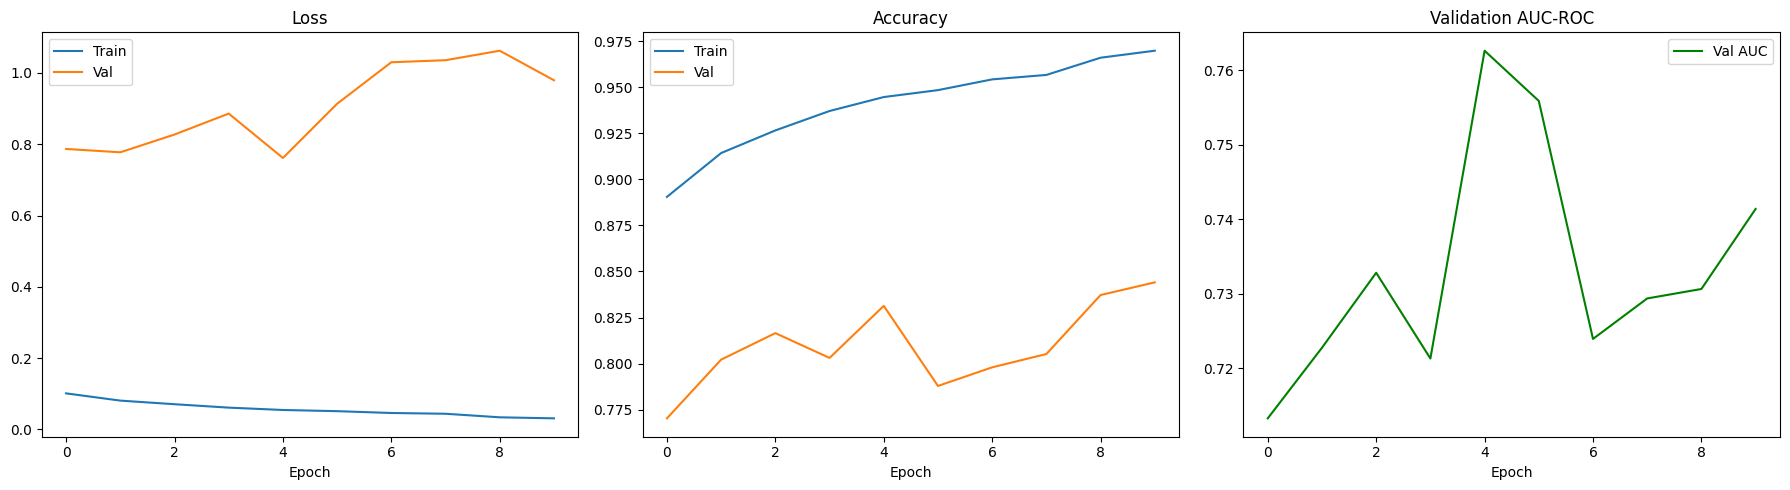

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history['val_auc'], label='Val AUC', color='green')
axes[2].set_title('Validation AUC-ROC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

**Learning Curve Interpretation:**

Training loss steadily decreases from 0.10 to 0.03 across all 10 epochs, while validation
loss initially decreases to a minimum of 0.76 at epoch 5 before climbing to 1.06 by epoch 9.
This divergence is a clear signal of overfitting, the model is memorizing training data
rather than learning generalizable features.

Training accuracy reaches 96.6% while validation accuracy plateaus around 80–83%, a gap of
approximately 15 percentage points. The learning rate scheduler reduced the rate from 1e-4
to 5e-5 at epoch 8, but validation metrics did not meaningfully improve, suggesting the
model had already converged to a suboptimal solution.

Validation AUC-ROC fluctuates between 0.71 and 0.76, peaking at epoch 5 (0.7626). The
instability of this metric across epochs, despite steady training improvement, further
indicates that the model's ranking of predictions is not reliably improving after early
training. The best model checkpoint was saved at epoch 5 based on this metric.

Test Loss: 1.4028
Test Accuracy: 0.7393
Test AUC-ROC: 0.7706

Classification Report:
              precision    recall  f1-score   support

        fake       0.76      0.86      0.81     12939
        real       0.67      0.52      0.58      7116

    accuracy                           0.74     20055
   macro avg       0.72      0.69      0.70     20055
weighted avg       0.73      0.74      0.73     20055



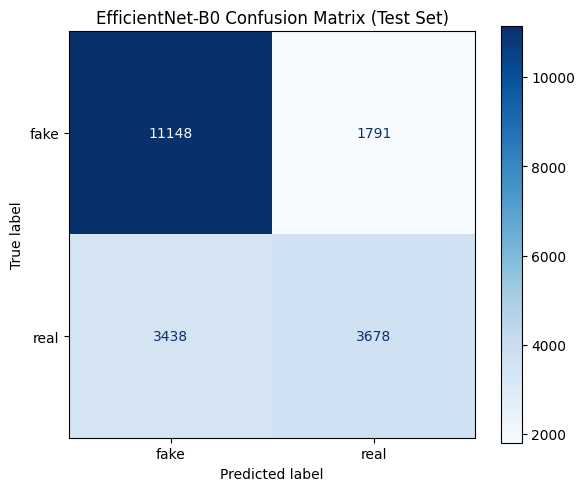

In [ ]:
# Evaluate on test set
test_loss, test_acc, test_auc, test_probs, test_labels = evaluate(
    model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC-ROC: {test_auc:.4f}")

# Classification report
test_preds = [1 if p > 0.5 else 0 for p in test_probs]
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=train_dataset.classes))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=train_dataset.classes)
disp.plot(ax=ax, cmap='Blues')
ax.set_title('EfficientNet-B0 Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

**Test Set Results and Confusion Matrix Interpretation:**

The model correctly identified 11,148 fakes (true positives) and 3,678 real images (true
negatives). However, 3,438 real images were incorrectly flagged as fake (false positives)
and 1,791 fakes were missed (false negatives).

The most significant finding is the asymmetry in per-class performance. Fake recall is
strong at 0.86, the model catches the majority of deepfakes. But real recall is only
0.52, meaning nearly half of all authentic images are incorrectly flagged. In a content
moderation deployment, this false positive rate would render the system impractical for
automated decisions and would require substantial human review.

The model's bias toward predicting "fake" reflects the 7:1 training class imbalance. Despite
the WeightedRandomSampler and weighted cross-entropy loss, the model defaults to the
majority class when uncertain. This is reflected in the precision gap: fake precision (0.76)
is higher than real precision (0.67), indicating the model is more selective about labeling
something "real" but still gets it wrong a third of the time.

**Primary evaluation metric:** Macro F1 = 0.70, which weights both classes equally. Overall
accuracy (73.93%) is a misleading metric here, a model predicting all-fake would score
64.5% accuracy on this test set. AUC-ROC (0.7706) provides the threshold-independent
baseline that subsequent models must exceed.

# Summary:
Trained an EfficientNet-B0 as the baseline CNN for deepfake detection. Then ussed ImageNet pretrained weights, froze the early layers,thawed the latter, and fine tuned the last two blocks plus the classifier head. Addressed the 7:1 class imbalance with a WeightedRandomSampler and weighted cross entropy loss.

**Results**: 73.93% test accuracy, 0.7706 AUC-ROC. The model is good at catching fakes (86% recall) but struggles with real images (52% recall). Nearly half of real frames get flagged as fake. Clear overfitting after epoch 5, with train loss dropping to 0.03 while val loss climbed above 1.0. Best model saved at epoch 5 based on validation AUC.

**Takeaways:** The model learns the task but defaults toward predicting fake, reflecting the training distribution despite balancing efforts. The big gap between fake F1 (0.81) and real F1 (0.58) shows the baseline hasn't truly learned to distinguish real from fake, it looks like its just gambling in a way, playing the odds if you will on the classes. Brightside is these weaknesses do give the ViT clear targets to beat in Weeks 3 and 4, especially real recall and AUC.